In [1]:
import copy
import snappy
import khovanov
import itertools
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from knot_graphs import *
from geography import *

## Approach: do band moves entirely within kh package
### ~~TODO - write `writhe` function for `khovanov.Link`~~
### ~~TODO - write `normal_euler_number` function for `khovanov.Cobordism`~~
### Question: is it the case that $e(F) = - e(F')$ where $F'$ is the surface obtained by mirroring the knots on either end?
### ~~TODO - plot $e(F)$ vs $b_1(F)$~~
### TODO (?) - plot Corollary 2.11 bound from Allen
$$
\left| \Upsilon_K(1) - \frac{\sigma(K)}{2} \right| \le \gamma_4(K)
$$
would give a horizontal line in the $e$-$b_1$ plane

In [2]:
def writhe(link : khovanov.Link):
    link.orient()
    n_plus, n_minus = link.get_signs()
    n = len([c for c in link.crossings if len(c.adjacent) == 4])
    if n_plus + n_minus != n:
        print('something went wrong!')
        print(f'link: {link}')
        print(f'n = {len(link.crossings)}, n+ = {n_plus}, n- = {n_minus}')
    writhe_ret = n_plus - n_minus
    return writhe_ret

In [3]:
def normal_euler_number(cob : khovanov.Cobordism):
    knot = cob.links[0]
    knot_prime = cob.links[-1]

    writhe_orig = writhe(knot)
    writhe_prime = writhe(knot_prime)
    e = writhe_prime - writhe_orig
    
    return e

In [4]:
K = snappy.Link('3_1')
K_kh = khovanov.Link(K.PD_code())

['arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15']
{(0, 1, 0): -0.15, (0, 1, 1): 0.15, (1, 2, 0): -0.15, (1, 2, 1): 0.15, (2, 0, 0): -0.15, (2, 0, 1): 0.15}


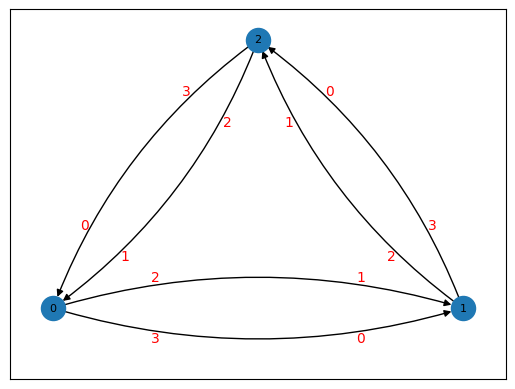

In [5]:
draw_adjacency_graph(K)

In [6]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(0, (0,0), (0,1))
print(normal_euler_number(cob))

6


### TODO - search for sequences of bands resulting in the unknot
1. Try a band
2. Attempt to simplify
3. If resulting knot is the unknot, we are done!
4. Otherwise, try another band.

WANT: list of band sequences taking $K$ to $\mathcal{U}$

Two approaches:
- Recursive search using depth tracking
- Iterative

In [7]:
# Example of a cobordism from 3_1 to the unknot U
S = khovanov.Cobordism(khovanov.Link(snappy.Link("3_1").PD_code()))
S.band_move(0, (1,3), (1,2))
S.finish()
print(S)
print(S.links)

('morse_saddle', [1-3, 1-2], 2-0)
('reidemeister_1', [1-2], (True, None))
('reidemeister_1', [0-2], (True, None))
('reidemeister_1', [2-0], (True, 2s))
('morse_death', [2s-0], None)

[Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (0, 0)], Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (1, 3), (1, 2)]
2 [(2, 1), (2, 0), (0, 1), (0, 0)], Link of 2 crossings:
0 [(2, 3), (2, 2), (0, 3), (0, 2)]
2 [(2, 1), (2, 0), (0, 1), (0, 0)], Link of 1 crossing:
2 [(2, 1), (2, 0), (2, 3), (2, 2)], Link of 1 crossing:
2s [(2s, 1), (2s, 0)], Link of 0 crossings.]


In [8]:
def try_bands_helper(cob : khovanov.Cobordism, prev_bands : list, max_depth=5, return_cob=False):
    if len(prev_bands) == max_depth: return []

    # only get full Crossings, not CrossingStrands
    crossings = [c for c in cob.links[-1].crossings if len(c.adjacent) == 4]
    strands = [0,1,2,3]
    # twists = [-1,0,1]
    twists = [0]
    cs_pairs = itertools.product(crossings, strands)

    results = []
    for twist in twists:
        for (c0,s0) in cs_pairs:
            for (c1, s1) in cs_pairs:
                if c0 == c1 and s0 == s1: continue

                cob_copy = copy.deepcopy(cob)
                try:
                    cob_copy.band_move(twist, (c0,s0), (c1,s1))
                    cob_copy.finish()
                except:
                    # if simplification fails then ignore this band
                    continue

                new_bands = prev_bands + [(twist, (c0,s0), (c1,s1))]

                # check if unknot reached
                if cob_copy.movie[-1][0] == 'morse_death' and len(cob_copy.links[-1].crossings) == 0:
                    if return_cob:
                        results.append((new_bands, cob_copy))
                    else: 
                        results.append(new_bands)
                else:
                    # try other bands
                    results.extend(try_bands_helper(cob_copy, new_bands, max_depth, return_cob))
    return results

def try_bands(knot : khovanov.Link, max_depth=5, return_cob=False):
    cob = khovanov.Cobordism(knot)
    return try_bands_helper(cob, [], max_depth, return_cob=return_cob)

In [ ]:
def draw_movie(K, band_seq):
  cob = khovanov.Cobordism(K)
  for band in band_seq:
    cob.band_move(band)

  for l in cbb.links:
    draw_adjacency_graph(l)
    plt.show()


In [9]:
K = khovanov.Link(snappy.Link("3_1").PD_code())
bands = try_bands(K, max_depth=3)

### TODO why doesn't this find `(0, (1,3), (1,2))`

In [10]:
bands

[[(0, (0, 0), (0, 1))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (0, 1)), (0, (1, 0), (1, 1))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (0, 3)), (0, (1, 0), (1, 1))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (1, 1)), (0, (0, 0), (0, 3))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 0)), (0, (0, 0), (0, 3))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 0)), (0, (0, 0), (1, 2))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 1)), (0, (0, 0), (0, 3))],
 [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 3)), (0, (0, 0), (0, 1))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (1, 1))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (1, 3))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 0)), (0, (1, 0), (1, 1))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 0)), (0, (1, 0), (1, 3))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 1)), (0, (1, 0), (1, 1))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 1)), (0, (1, 0), (1, 3))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 2)), (0, (1, 0), (1, 1))],
 [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 2)), (0, (1, 0), (1, 3))],
 [(0, (0, 0), (0, 3)), (0, (

In [11]:
len(bands)

89

In [12]:
S = khovanov.Cobordism(K)
S.band_move(-1, (0,0), (0,1))
S.finish()
S.band_move(-1, (2,0), (2,1))
S.finish()
print(S); print(S.links)

('reidemeister_1_up', [0-0, True], 3-3)
('morse_saddle', [3-3, 0-1], 3-2)
('reidemeister_2', [0-0, 0-1], (0, 3, 1-0, 2-2))
('reidemeister_1_up', [2-0, True], 3-3)
('morse_saddle', [3-3, 2-1], 3-2)
('reidemeister_2', [1-2, 1-3], (1, 3, 2-2, 2-0))
('reidemeister_1', [2-1], (False, 2s))
('morse_death', [2s-0], None)

[Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (0, 0)], Link of 4 crossings:
0 [(3, 0), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (3, 1)]
3 [(0, 0), (2, 3), (3, 3), (3, 2)], Link of 4 crossings:
0 [(3, 0), (3, 3), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (3, 2), (3, 1)]
3 [(0, 0), (2, 3), (2, 2), (0, 1)], Link of 2 crossings:
1 [(2, 3), (2, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (1, 1), (1, 0)], Link of 3 crossings:
1 [(2, 3), (2, 2), (2, 1), (3, 1)]
2 [(3, 0), (1, 2), (1, 1), (1, 0)]
3 [(2, 0), (1, 3), (3, 3), (3, 2)], Link of 3 cro

#### Old `try_bands` code

In [13]:
#def try_bands(knot : khovanov.Link):
#    crossings = knot.crossings
#    strands = [0,1,2,3]
#    good_bands = 0
#    failed_bands = 0
#    twists = []
#    c0s = []
#    s0s = []
#    c1s = []
#    s1s = []
#    es = []
#    for twist in [-1,0,1]:
#        for (c0, s0) in itertools.product(crossings, strands):
#            for (c1, s1) in itertools.product(crossings, strands):
#                if c0 == c1 and s0 == s1: continue
#                try:
#                    cob = khovanov.Cobordism(knot)
#                    cob.band_move(twist, (c0,s0), (c1,s1))
#                    e = normal_euler_number(cob)
#                    
#                    twists.append(twist)
#                    c0s.append(c0)
#                    s0s.append(s0)
#                    c1s.append(c1)
#                    s1s.append(s1)
#                    es.append(e)
#                    
#                    good_bands += 1
#                except:
#                    failed_bands += 1
#                    continue
#
#    print(f'bands found: {good_bands}')
#    print(f'number of failed band moves: {failed_bands}')
#    
#    return pd.DataFrame(zip(twists, c0s, s0s, c1s, s1s, es),
#                        columns=['twist', 'c0', 's0', 'c1', 's1', 'e'])

#### Band move plotting on $e$-$b_1$ plane

In [14]:
def plot_bands_to_unknot(K_snappy : snappy.Link, max_depth=3,
                         erange=(-40,40), brange=(0,30), knot_name=None):
    if knot_name is None:
        knot_name = "?"
        
    fig, ax = plot_bounds(K_snappy, erange=erange, brange=brange,
                          plot_intersection=False)

    K_khov = khovanov.Link(K_snappy.PD_code())
    band_seqs = try_bands(K_khov, max_depth=max_depth, return_cob=True)

    es = [normal_euler_number(cob) for _,cob in band_seqs]
    bs = [len(seq) for seq,_ in band_seqs]

    for (seq,_),e,b in zip(band_seqs, es, bs):
        print(f'e={e}, b={b}: {seq}')

    ax.scatter(es, bs, c='red', s=6)
    ax.set_title(f'Possible planar bands on ' + knot_name)
                    
    return fig, ax

### Trefoil $3_1$

e=3, b=1: [(0, (0, 0), (0, 1))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (0, 1)), (0, (1, 0), (1, 1))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (0, 3)), (0, (1, 0), (1, 1))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (1, 1)), (0, (0, 0), (0, 3))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 0)), (0, (0, 0), (0, 3))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 0)), (0, (0, 0), (1, 2))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 1)), (0, (0, 0), (0, 3))]
e=3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 3)), (0, (0, 0), (0, 1))]
e=3, b=2: [(0, (0, 0), (0, 3)), (0, (1, 0), (1, 1))]
e=3, b=2: [(0, (0, 0), (0, 3)), (0, (1, 0), (1, 3))]
e=3, b=3: [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 0)), (0, (1, 0), (1, 1))]
e=3, b=3: [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 0)), (0, (1, 0), (1, 3))]
e=3, b=3: [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 1)), (0, (1, 0), (1, 1))]
e=3, b=3: [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 1)), (0, (1, 0), (1, 3))]
e=3, b=3: [(0, (0, 0), (0, 3)), (0, (1, 0), (2, 

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on $3_1$'}, xlabel='$e$', ylabel='$b_1$'>)

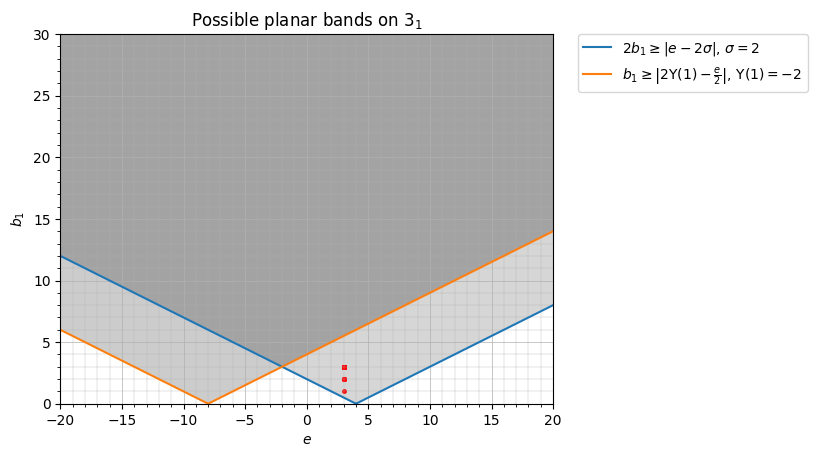

In [15]:
trefoil = snappy.Link('3_1')
plot_bands_to_unknot(trefoil, erange=(-20,20), knot_name='$3_1$')

### Mirrored trefoil $-3_1$

e=-3, b=2: [(0, (0, 0), (0, 1)), (0, (1, 0), (1, 1))]
e=-3, b=2: [(0, (0, 0), (0, 1)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 0)), (0, (1, 0), (1, 1))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 0)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 1)), (0, (1, 0), (1, 1))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 1)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 2)), (0, (1, 0), (1, 1))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 2)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 3)), (0, (1, 0), (1, 1))]
e=-3, b=3: [(0, (0, 0), (0, 1)), (0, (1, 0), (2, 3)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (0, 1)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (0, 3)), (0, (1, 0), (1, 3))]
e=-3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (1, 3)), (0, (0, 0), (0, 1))]
e=-3, b=3: [(0, (0, 0), (0, 2)), (0, (0, 0), (2, 0)), (0, (0, 0), (

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on $-3_1$'}, xlabel='$e$', ylabel='$b_1$'>)

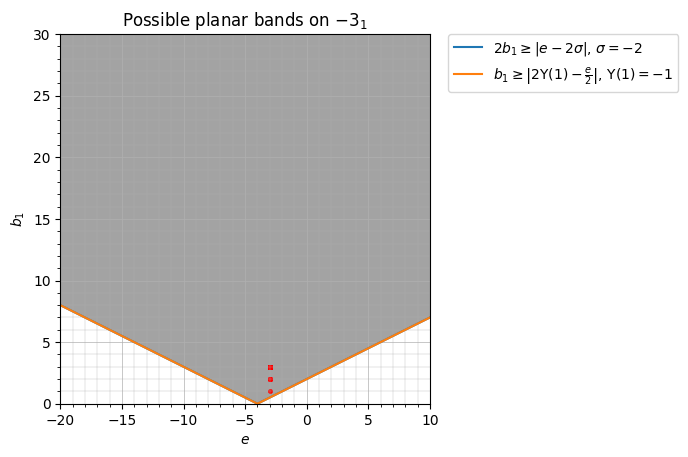

In [16]:
plot_bands_to_unknot(trefoil.mirror(), erange=(-20,10), knot_name='$-3_1$')

### Torus Knots $T(4,q)$

In [17]:
T45 = snappy.Link('T(4,5)')
T45_kh = khovanov.Link(T45.PD_code())

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on T(4,5)'}, xlabel='$e$', ylabel='$b_1$'>)

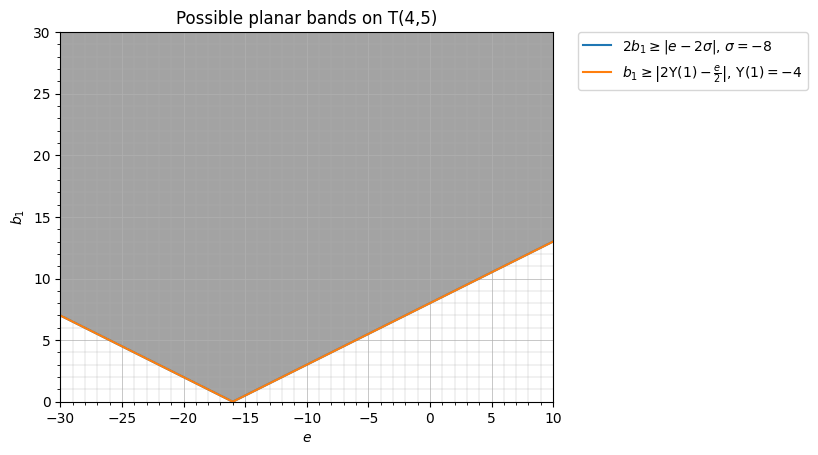

In [18]:
plot_bands_to_unknot(T45, max_depth=1, erange=(-30,10), knot_name='T(4,5)')

In [19]:
T47 = snappy.Link('T(4,7)')
T47_kh = khovanov.Link(T45.PD_code())

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Possible planar bands on T(4,7)'}, xlabel='$e$', ylabel='$b_1$'>)

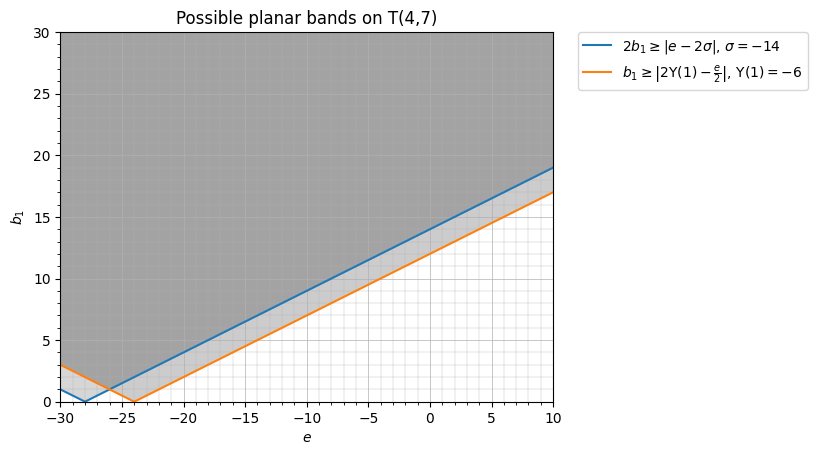

In [20]:
plot_bands_to_unknot(T47, max_depth=1, erange=(-30,10), knot_name='T(4,7)')

## ~~Approach - write band move function from scratch~~

### Bands are described by paths in the dual graph with additional data about over/under crossings at strand intersections

### TODO - draw dual graph on top of adjacency crossing graph

#### the goal here is to draw the dual graph over top of the knot diagram itself

In [21]:
K = snappy.Link('4_1')
dg = K.dual_graph()

In [22]:
vars(dg)

{'vertices': {<F0>, <F1>, <F2>, <F3>, <F4>, <F5>},
 'edges': {<F0> --- <F1>,
  <F0> --- <F3>,
  <F0> --- <F4>,
  <F1> --- <F2>,
  <F2> --- <F3>,
  <F2> --- <F4>,
  <F3> --- <F5>,
  <F4> --- <F5>},
 'incidence_dict': {<F0>: [<F0> --- <F1>, <F0> --- <F3>, <F0> --- <F4>],
  <F1>: [<F0> --- <F1>, <F1> --- <F2>],
  <F3>: [<F0> --- <F3>, <F2> --- <F3>, <F3> --- <F5>],
  <F4>: [<F0> --- <F4>, <F2> --- <F4>, <F4> --- <F5>],
  <F2>: [<F1> --- <F2>, <F2> --- <F3>, <F2> --- <F4>],
  <F5>: [<F3> --- <F5>, <F4> --- <F5>]},
 'Edge': spherogram.graphs.Edge,
 'edge_to_face': {<CS 3, 3>: <F0>,
  <CS 0, 3>: <F0>,
  <CS 2, 1>: <F0>,
  <CS 3, 2>: <F1>,
  <CS 2, 2>: <F1>,
  <CS 3, 1>: <F2>,
  <CS 2, 3>: <F2>,
  <CS 1, 3>: <F2>,
  <CS 3, 0>: <F3>,
  <CS 1, 0>: <F3>,
  <CS 0, 2>: <F3>,
  <CS 2, 0>: <F4>,
  <CS 0, 0>: <F4>,
  <CS 1, 2>: <F4>,
  <CS 1, 1>: <F5>,
  <CS 0, 1>: <F5>}}

In [23]:
dg_nx = dg.to_networkx()

In [24]:
dg_nx.nodes.data()

NodeDataView({<F0>: {}, <F3>: {}, <F5>: {}, <F2>: {}, <F4>: {}, <F1>: {}})

In [25]:
dg_nx.edges

MultiEdgeView([(<F0>, <F1>, 0), (<F0>, <F3>, 0), (<F0>, <F4>, 0), (<F3>, <F5>, 0), (<F3>, <F2>, 0), (<F5>, <F4>, 0), (<F2>, <F1>, 0), (<F2>, <F4>, 0)])

In [26]:
def draw_dual_graph(knot):
    dg = knot.dual_graph().to_networkx()
    layout = nx.spring_layout(dg)
    nx.draw_networkx(dg, pos=layout)
    #nx.draw_networkx_labels(dg, pos=layout, font_size=10)

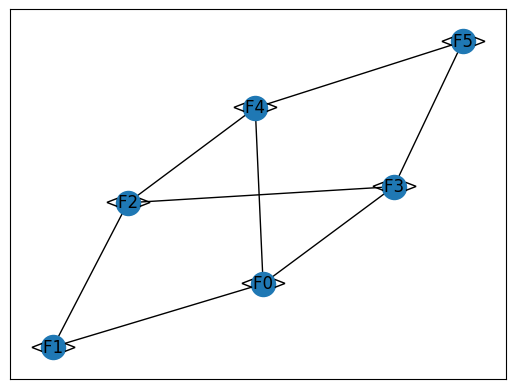

In [27]:
draw_dual_graph(K)

['arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0']
{(0, 1, 0): -0.15, (0, 3, 0): 0, (1, 0, 0): -0.15, (1, 2, 0): 0, (2, 3, 0): -0.15, (2, 0, 0): 0, (3, 2, 0): -0.15, (3, 1, 0): 0}


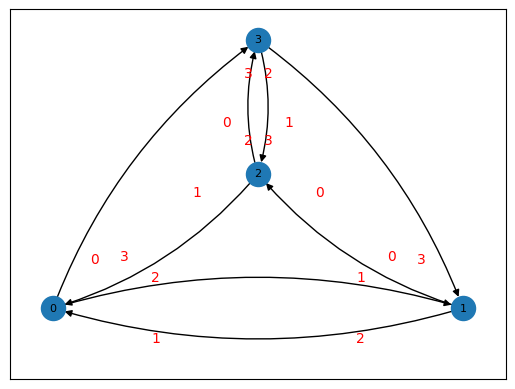

In [28]:
draw_adjacency_graph(K)